# Captsone project : Eye for Blind
This notebook will be used to prepare the capstone project 'Eye for Blind'

# Step I : Import all relevant libraries

In [80]:
#Import all the required libraries
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from PIL import Image
from PIL import ImageFont
from PIL import ImageDraw 
from pickle import dump,load
from tqdm import tqdm
from collections import Counter

In [81]:
import keras
from keras.models import Sequential
from keras.preprocessing import sequence
from keras.preprocessing.text import Tokenizer
from keras.optimizers import Adam, RMSprop
from keras.layers import Bidirectional
from keras.layers import add
from keras.applications.inception_v3 import InceptionV3
from keras.preprocessing import image
from keras.models import Model
from keras.applications.inception_v3 import preprocess_input
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

from nltk.corpus import stopwords
from nltk.translate.bleu_score import sentence_bleu

import tensorflow as tf
from tensorflow.keras import Input, layers
from tensorflow.keras import optimizers
from tensorflow.keras.layers import LSTM, Embedding, TimeDistributed, Dense, RepeatVector,\
                         Activation, Flatten, Reshape, concatenate, Dropout, BatchNormalization, Conv2D

In [82]:
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_colwidth', 100)

## Step II : Data understanding
1. Load the dataset and separate the images and captions into two distinct variables.
2. Display the images alongside their corresponding captions from the dataset.
3. Construct a DataFrame summarizing the image, file path, and captions.
4. Generate a list containing all the captions and their respective file paths.
5. Visualize the 30 most frequently occurring words in the captions.



### 2.1 : Data Sourcing 

In [83]:
IMAGES_DIR = 'Images'
CAPTIONS_FILE = 'captions.txt'
OUTPUT_IMAGE_PATH = "working/Image/"

In [11]:
#Import the dataset and read the image into a seperate variable

all_imgs = glob.glob(IMAGES_DIR + '/*.jpg',recursive=True)
print("The total images present in the dataset: {}".format(len(all_imgs)))

The total images present in the dataset: 8091


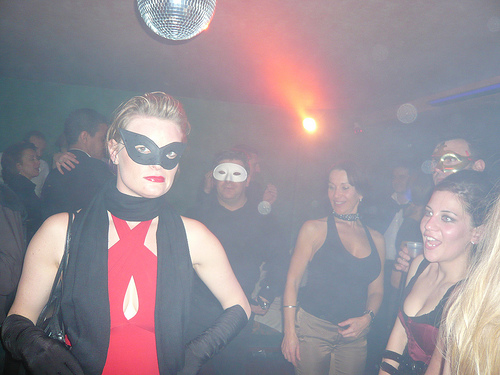

In [12]:
#Visualise both the images & text present in the dataset
Image.open(all_imgs[0])

In [13]:
#Import the dataset and read the text file into a seperate variable

def load_doc(filename):
    
    text=open(filename).read()    
    return text

doc = load_doc(CAPTIONS_FILE)
print(doc[:300])

image,caption
1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .
1000268201_693b08cb0e.jpg,A girl going into a wooden building .
1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
1000268201_693b08cb0e.jpg,A little girl climbing


### 2.2 : Create a dataframe which summarizes the image, path & captions as a dataframe

Each image ID is linked to 5 captions, resulting in a total of 40,455 samples in the dataset.

In [14]:
def get_img_ids_and_captions(text):
    keys=[]
    values=[]
    key_paths=[]
    text=text.splitlines()[1:]

    for line in text:
        com_idx=line.index(",")
        im_id,im_cap=line[:com_idx], line[com_idx+1:]
        keys.append(im_id)
        values.append(im_cap)
        key_paths.append(IMAGES_DIR +'/'+ im_id)

    return keys, values, key_paths

In [15]:
all_img_id,annotations,all_img_vector = get_img_ids_and_captions(doc)#store all the image id here

df = pd.DataFrame(list(zip(all_img_id, all_img_vector,annotations)),columns =['ID', 'Path', 'Captions']) 
    
df.head(5)

,ID,Path,Captions
0,1000268201_693b08cb0e.jpg,Images/1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .
1,1000268201_693b08cb0e.jpg,Images/1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,Images/1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,Images/1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .
4,1000268201_693b08cb0e.jpg,Images/1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a wooden cabin .


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40455 entries, 0 to 40454
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ID        40455 non-null  object
 1   Path      40455 non-null  object
 2   Captions  40455 non-null  object
dtypes: object(3)
memory usage: 948.3+ KB


### 2.3 : Create a list of captions

In [17]:
#Create a list which contains all the captions
annotations = df.Captions.apply(lambda x:'<start> '+ x + ' <end>').to_list()

#Create a list which contains all the path to the images
all_img_path = df.Path.to_list()#write your code here

print("Total captions present in the dataset: "+ str(len(annotations)))
print("Total images present in the dataset: " + str(len(all_img_path)))

Total captions present in the dataset: 40455
Total images present in the dataset: 40455


### 2.4 : Create the vocabulary & the counter for the captions

In [18]:
#Create the vocabulary & the counter for the captions

def voc_fetcher(frame,column):
    out=[]
    for i in frame[column]:
        out+=i.split(" ")
    return out


vocabulary=voc_fetcher(df,"Captions")
val_count=Counter(vocabulary)

print(f"Size of Vocab : {len(set(vocabulary))}")
val_count


Size of Vocab : 9862


Counter({'A': 21481,
         'child': 1477,
         'in': 18961,
         'a': 40271,
         'pink': 734,
         'dress': 347,
         'is': 9345,
         'climbing': 502,
         'up': 1260,
         'set': 108,
         'of': 6712,
         'stairs': 109,
         'an': 1944,
         'entry': 1,
         'way': 50,
         '.': 34212,
         'girl': 3217,
         'going': 149,
         'into': 1074,
         'wooden': 284,
         'building': 509,
         'little': 1625,
         'playhouse': 6,
         'the': 15328,
         'to': 3173,
         'her': 1178,
         'cabin': 4,
         'black': 3696,
         'dog': 7982,
         'and': 8850,
         'spotted': 37,
         'are': 3503,
         'fighting': 132,
         'tri-colored': 14,
         'playing': 2008,
         'with': 7760,
         'each': 430,
         'other': 771,
         'on': 10729,
         'road': 388,
         'white': 3875,
         'brown': 2475,
         'spots': 29,
         'staring'

### 2.5 : Visualize the top 30 words 

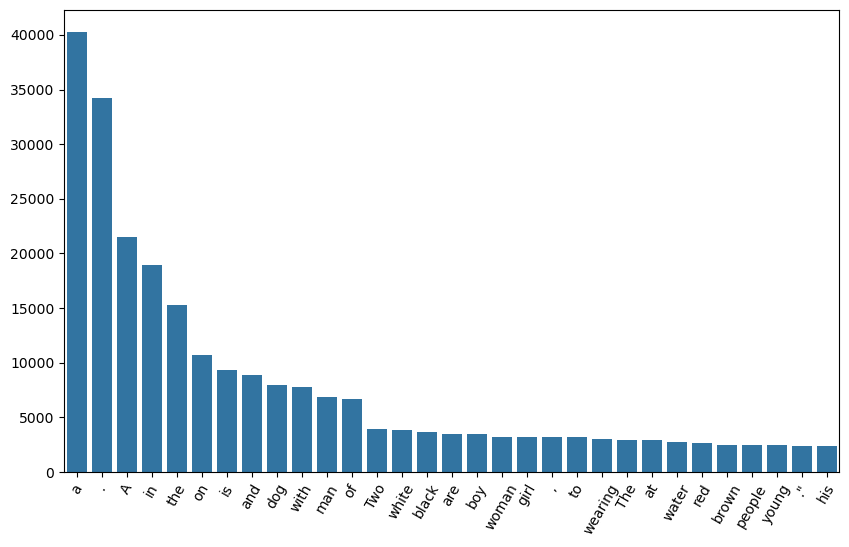

In [19]:
# Visualise the top 30 occuring words in the captions
def get_top_words_based_on_cnt(words_dict,n_words):
    n_words+=1
    keys=list(words_dict.keys())
    values=list(words_dict.values())
    sorted_values=sorted(values,reverse=True)[:n_words]
    sorted_keys=[]
    for i in sorted_values:
        if sorted_values.count(i)==1:
            sorted_keys.append(keys[values.index(i)])
        elif sorted_values.count(i)==2:
            f_idx=values.index(i)
            s_idx=values[f_idx+1:].index(i)
            s_idx+=f_idx+1
            a,b=keys[f_idx],keys[s_idx]
            if a not in sorted_keys and b not in sorted_keys:
                sorted_keys.append(a)
                sorted_keys.append(b)
    plt.figure(figsize=(10,6))
    sns.barplot(x=sorted_keys,y=sorted_values)
    plt.xticks(rotation=60)
    plt.show()
    #write your code here
get_top_words_based_on_cnt(val_count,30)

## Step III:  Pre-processing the captions
1. Tokenize the captions to create tokenized vectors by splitting them using spaces and applying filters. This process generates a vocabulary of unique words from the dataset. Limit the total vocabulary to the top 5,000 words to conserve memory.
2. Replace any words outside the top 5,000 with the **`UNK`** token to represent unknown words.
3. Create mappings for **word-to-index** and **index-to-word** conversions.
4. Pad all sequences to match the length of the longest sequence in the dataset.

### 3.1 : Tokenizer

In [20]:
# create the tokenizer

top_word_cnt = 5000
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=top_word_cnt,oov_token="<unk>",filters='!"#$%&()*+.,-/:;=?@[\]^_`{|}~ ')
tokenizer.fit_on_texts(annotations)
train_seqs = tokenizer.texts_to_sequences(annotations)
train_seqs[:5]

[[3, 2, 44, 5, 2, 91, 173, 8, 120, 52, 2, 394, 13, 395, 5, 29, 1, 671, 4],
 [3, 2, 20, 317, 65, 2, 197, 118, 4],
 [3, 2, 41, 20, 120, 65, 2, 197, 2438, 4],
 [3, 2, 41, 20, 120, 6, 395, 21, 61, 2438, 4],
 [3, 2, 41, 20, 5, 2, 91, 173, 317, 65, 2, 197, 2982, 4]]

### 3.2 : Word to index and index to word mapping

In [21]:
# Create word-to-index and index-to-word mappings.

tokenizer.word_index['<pad>'] = 0
tokenizer.index_word[0] = '<pad>'
train_seqs = tokenizer.texts_to_sequences(annotations)

In [22]:
tokenizer.word_counts

OrderedDict([('<start>', 40455),
             ('a', 62992),
             ('child', 1545),
             ('in', 18986),
             ('pink', 739),
             ('dress', 348),
             ('is', 9345),
             ('climbing', 507),
             ('up', 1302),
             ('set', 109),
             ('of', 6723),
             ('stairs', 109),
             ('an', 2432),
             ('entry', 1),
             ('way', 53),
             ('<end>', 40455),
             ('girl', 3328),
             ('going', 149),
             ('into', 1074),
             ('wooden', 284),
             ('building', 510),
             ('little', 1768),
             ('playhouse', 6),
             ('the', 18419),
             ('to', 3176),
             ('her', 1178),
             ('cabin', 4),
             ('black', 3848),
             ('dog', 8138),
             ('and', 8862),
             ('spotted', 38),
             ('are', 3504),
             ('fighting', 133),
             ('tri', 14),
             ('color

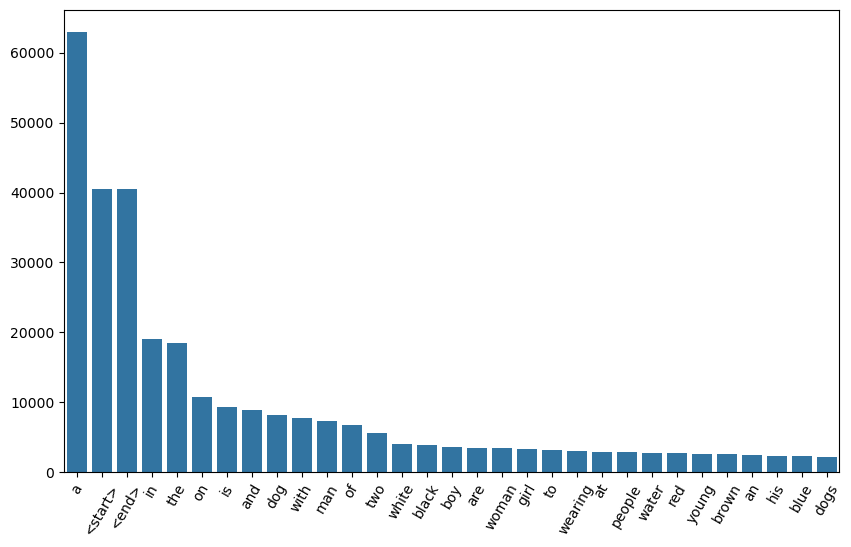

In [23]:
# Create a word count of your tokenizer to visulize the Top 30 occuring words after text processing

get_top_words_based_on_cnt(tokenizer.word_counts,30)

In [24]:
def min_max_for_nested_array(nested_array):
    array=[len(e) for e in nested_array]
    return min(array),max(array)

min_l, max_l = min_max_for_nested_array(train_seqs)
print(f'Max Sequence Length of the Texts is: {max_l}')

cap_vector= tf.keras.preprocessing.sequence.pad_sequences(train_seqs, padding='post', maxlen=max_l)
print("The shape of Caption vector is :" + str(cap_vector.shape))

Max Sequence Length of the Texts is: 39
The shape of Caption vector is :(40455, 39)


## Step IV : Pre-processing the images

1. Resize the images to dimensions of **(299, 299)**.
2. Normalize the images to a range of -1 to 1 to ensure compatibility with the **InceptionV3** model format.

### FAQs on how to resize the images::
* Start by converting the list of image paths into a dataset using `tf.data.Dataset.from_tensor_slices`. This will create a TensorFlow dataset containing the image paths.
* Next, define and apply a function to this dataset to preprocess each image. This function should handle resizing the images and perform the necessary preprocessing to ensure compatibility with the `InceptionV3` format.


In [30]:
# Creating the function. This function should return images & their path

def load_the_image(image_path):
    my_img = tf.io.read_file(image_path)
    my_img = tf.image.decode_jpeg(my_img, channels=3)
    my_img = tf.image.resize(my_img, (299, 299))
    my_img = tf.keras.applications.inception_v3.preprocess_input(my_img)
    
    return my_img, image_path


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


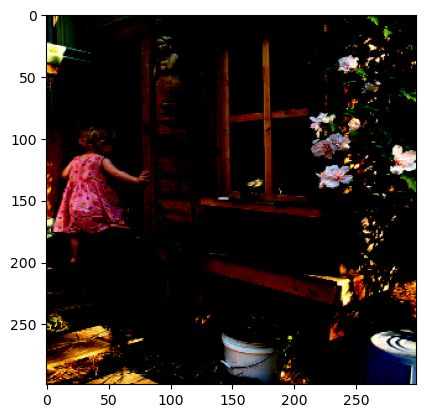

In [31]:
plt.imshow(load_the_image(all_img_path[0])[0])

In [32]:
#write your code here for applying the function to the image path dataset, such that the transformed dataset should contain images & their path
encode_train_set = sorted(set(all_img_vector))

feature_dict = {}

image_data_set = tf.data.Dataset.from_tensor_slices(encode_train_set)
image_data_set = image_data_set.map(load_image, num_parallel_calls=tf.data.experimental.AUTOTUNE).batch(32)

## Step V :  Load the pretrained Imagenet weights of Inception net V3

1. To conserve memory and prevent RAM exhaustion, extract image features using the last layer of a pre-trained model. Including feature extraction directly in the training process would significantly increase computational time.
2. The output from this layer has a shape of **8x8x2048**.
3. Use a function to extract features for each image in the training and testing datasets, ensuring the shape of each image is **(batch_size, 8*8, 2048)**.



In [33]:
image_model = tf.keras.applications.InceptionV3(include_top=False,weights='imagenet')

new_input = image_model.input 
hidden_layer = image_model.layers[-1].output 

image_features_extract_model = keras.Model(new_input, hidden_layer) 

87910968/87910968 [==============================] - 13s 0us/step


In [34]:
image_features_extract_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, None, None, 3)]      0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, None, None, 32)       864       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, None, None, 32)       96        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, None, None, 32)       0         ['batch_normalization[0][0

### FAQs on how to store the features:
* You can save the extracted features in a dictionary, using the image path as the key and the features generated by the `InceptionV3` model as the values.
* Alternatively, you can use NumPy’s `np.save` to store the resulting feature vectors as files.

## Step VI : Dataset creation
1. Apply train_test_split to both image paths and captions to create training and testing lists. Use an **80-20** split ratio with `random_state=42` for reproducibility.

2. Create a function to map image paths to their corresponding extracted features.

3. Develop a builder function to construct the training and testing datasets. Apply the mapping function created earlier to preprocess the datasets.

4. Ensure that shuffling and batching are performed while building the datasets.

5. The shape of each image in the dataset after processing should be **(batch_size, 8*8, 2048)**.

6. The shape of each caption in the dataset after processing should be **(batch_size, max_len)**.


In [35]:
path_train, path_test, cap_train, cap_test = train_test_split(all_img_vector,
                                                              cap_vector,
                                                              test_size=0.2,
                                                              random_state=33)

In [36]:
print("Training data for images: " + str(len(path_train)))
print("Testing data for images: " + str(len(path_test)))
print("Training data for Captions: " + str(len(cap_train)))
print("Testing data for Captions: " + str(len(cap_test)))

Training data for images: 32364
Testing data for images: 8091
Training data for Captions: 32364
Testing data for Captions: 8091


In [37]:
# Create a function which maps the image path to their feature. 
# This function will take the image_path & caption and return it's feature & respective caption.

def map_func(image_name, capt):
  
  img_tensor = feature_dict[image_name.decode('utf-8')]
  return img_tensor, capt

In [38]:
for image, path in tqdm(image_data_set):

    batch_features = image_features_extract_model(image)
    batch_features = tf.reshape(batch_features,(batch_features.shape[0], -1, batch_features.shape[3]))
    
    for batch_f, p in zip(batch_features, path):
        path_of_feature = p.numpy().decode("utf-8")
        feature_dict[path_of_feature] =  batch_f.numpy()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 253/253 [01:58<00:00,  2.13it/s]


In [39]:
batch_f.shape

TensorShape([64, 2048])

### FAQs on how to load the features:
* You can load the features from the previously created dictionary.
* Alternatively, you can use NumPy’s `np.load` to load the stored feature vectors.

In [40]:
# create a builder function to create dataset which takes in the image path & captions as input
# This function should transform the created dataset(img_path,cap) to (features,cap) using the map_func created earlier
BATCH_SIZE = 32
BUFFER_SIZE = 1000
def gen_dataset(images_data, captions_data):
    
    dataset = tf.data.Dataset.from_tensor_slices((images_data, captions_data))
    dataset = dataset.shuffle(BUFFER_SIZE)

    dataset = dataset.map(lambda item1, item2: tf.numpy_function(
          map_func, [item1, item2], [tf.float32, tf.int32]),
          num_parallel_calls=tf.data.experimental.AUTOTUNE).batch(BATCH_SIZE)

    dataset = dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

    return dataset



In [41]:
train_dataset=gen_dataset(path_train, cap_train)
test_dataset=gen_dataset(path_test, cap_test)

In [42]:
sample_img_batch, sample_cap_batch = next(iter(train_dataset))
print(sample_img_batch.shape)  #(batch_size, 8*8, 2048)
print(sample_cap_batch.shape) #(batch_size,max_len)

(32, 64, 2048)
(32, 39)


## Step VII : Model Building

### 7.1 
1. Define the required parameters.
2. Construct the **Encoder**, **Attention Mechanism**, and **Decoder** models.

In [43]:
embedding_dim = 256 
units = 512
vocab_size = 5001 #top 5,000 words +1
train_num_steps = len(path_train) // BATCH_SIZE
test_num_steps = len(path_test) // BATCH_SIZE

### 7.2 Encoder

In [44]:
class Encoder(Model):
    def __init__(self,embed_dim):
        super(Encoder, self).__init__()
        self.dense = layers.Dense(embed_dim)
        self.dropout = layers.Dropout(0.5)
        
    def call(self, features):
        features =  self.dense(features)
        features = tf.nn.relu(features)
        return features

In [45]:
encoder=Encoder(embedding_dim)

### 7.3 Attention model

In [46]:
class Attention_model(Model):
    def __init__(self, units):
        super(Attention_model, self).__init__()
        self.W1 = layers.Dense(units)
        self.W2 = layers.Dense(units)
        self.V = layers.Dense(1)
        self.units=units

    def call(self, features, hidden):
        # features shape: (batch_size, 8*8, embedding_dim)
        # hidden shape: (batch_size, hidden_size)
        hidden_with_time_axis =  tf.expand_dims(hidden, 1)
        score = keras.activations.tanh(self.W1(features) + self.W2(hidden_with_time_axis))
        attention_weights =  keras.activations.softmax(self.V(score), axis=1)
        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector, attention_weights

### 7.4 Decoder

In [47]:
class Decoder(Model):

    def __init__(self, embed_dim, units, vocab_size):
        super(Decoder, self).__init__()
        self.units=units
        self.attention = Attention_model(self.units)
        self.embedding = layers.Embedding(vocab_size, embedding_dim)
        self.gru = layers.GRU(self.units,
                                   return_sequences=True,
                                   return_state=True,
                                   recurrent_initializer='glorot_uniform')
        self.d1 = layers.Dense(self.units)
        self.d2 = layers.Dense(vocab_size)
        
    def call(self,x,features, hidden):

        context_vector, attention_weights = self.attention(features, hidden)
        embed =  self.embedding(x)
        embed =  tf.concat([tf.expand_dims(context_vector, 1), embed], axis=-1)
        output, state = self.gru(embed)
        output = self.d1(output)
        output = tf.reshape(output, (-1, output.shape[2])) # shape : (batch_size * max_length, hidden_size)
        output = self.d2(output) # shape : (batch_size * max_length, vocab_size)
        
        return output, state, attention_weights
    
    def init_state(self, batch_size):
        return tf.zeros((batch_size, self.units))

In [48]:
decoder=Decoder(embedding_dim, units, vocab_size)

In [49]:
features=encoder(sample_img_batch)

hidden = decoder.init_state(batch_size=sample_cap_batch.shape[0])
dec_input = tf.expand_dims([tokenizer.word_index['<start>']] * sample_cap_batch.shape[0], 1)

predictions, hidden_out, attention_weights= decoder(dec_input, features, hidden)
print('Feature shape from Encoder: {}'.format(features.shape)) 
print('Predcitions shape from Decoder: {}'.format(predictions.shape)) 
print('Attention weights shape from Decoder: {}'.format(attention_weights.shape)) 

Feature shape from Encoder: (32, 64, 256)
Predcitions shape from Decoder: (32, 5001)
Attention weights shape from Decoder: (32, 64, 1)


## Step VIII : Model training & optimization
1. Configure the optimizer and loss function.
2. Define the checkpoint directory and path.
3. Develop the training and testing step functions.
4. Implement the loss function for the testing dataset.

In [50]:
optimizer = keras.optimizers.Adam()
loss_object = keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

In [51]:
def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)

    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask

    return tf.reduce_mean(loss_)

In [52]:
checkpoint_path = os.path.join("checkpoints", "train")
ckpt = tf.train.Checkpoint(encoder=encoder,
                           decoder=decoder,
                           optimizer = optimizer)
ckpt_manager = tf.train.CheckpointManager(ckpt, checkpoint_path, max_to_keep=5)

In [53]:
start_epoch = 0
if ckpt_manager.latest_checkpoint:
    start_epoch = int(ckpt_manager.latest_checkpoint.split('-')[-1])

* During the training step of your model, implement the technique of teacher forcing.
* `Teacher forcing` involves using the actual target/ground truth word as the next input to the decoder, rather than relying on the previous prediction.

In [54]:
@tf.function
def train_step(img_tensor, target):
    loss = 0

    hidden = decoder.init_state(batch_size=target.shape[0])
    dec_input = tf.expand_dims([tokenizer.word_index['<start>']] * target.shape[0], 1)

    with tf.GradientTape() as tape:
        features = encoder(img_tensor)

        for i in range(1, target.shape[1]):
            predictions, hidden, _ = decoder(dec_input, features, hidden)
            loss += loss_function(target[:, i], predictions)
            dec_input = tf.expand_dims(target[:, i], 1)

        avg_loss = (loss/int(target.shape[1]))
        trainable_variables = encoder.trainable_variables + decoder.trainable_variables
        gradients = tape.gradient(loss, trainable_variables)
        optimizer.apply_gradients(zip(gradients, trainable_variables))
        
        return loss, avg_loss

* In the testing step of your model, the previous prediction will be used as the next input to the decoder.

In [55]:
@tf.function
def test_step(img_tensor, target):
    loss = 0
    hidden = decoder.init_state(batch_size=target.shape[0])
    dec_input = tf.expand_dims([tokenizer.word_index['<start>']] * target.shape[0], 1)

    with tf.GradientTape() as tape:
        features = encoder(img_tensor)

        for i in range(1, target.shape[1]):
            predictions, hidden, _ = decoder(dec_input, features, hidden)
            loss += loss_function(target[:, i], predictions)
            dec_input = tf.expand_dims(target[:, i], 1)

        avg_loss = (loss / int(target.shape[1]))

        trainable_variables = encoder.trainable_variables + decoder.trainable_variables
        gradients = tape.gradient(loss, trainable_variables)
        optimizer.apply_gradients(zip(gradients, trainable_variables))

        return loss, avg_loss

In [56]:
def test_loss_cal(test_dataset):
    total_loss = 0
    
    for (batch, (img_tensor, target)) in enumerate(test_dataset):
        batch_loss, t_loss = test_step(img_tensor, target)
        total_loss += t_loss

    avg_test_loss = total_loss/test_num_steps

    return avg_test_loss

In [69]:
loss_plot = []
test_loss_plot = []
EPOCHS = 15

best_test_loss=100
for epoch in tqdm(range(0, EPOCHS)):
    start = time.time()
    total_loss = 0

    for (batch, (img_tensor, target)) in enumerate(train_dataset):
        batch_loss, t_loss = train_step(img_tensor, target)
        total_loss += t_loss
        avg_train_loss=total_loss / train_num_steps
        
    loss_plot.append(avg_train_loss)    
    test_loss = test_loss_cal(test_dataset)
    test_loss_plot.append(test_loss)
    
    print ('For epoch: {}, the train loss is {:.3f}, & test loss is {:.3f}'.format(epoch+1, avg_train_loss, test_loss))
    print ('Time taken for 1 epoch {} sec\n'.format(time.time() - start))
    
    if test_loss < best_test_loss:
        print('Test loss has been reduced from %.3f to %.3f' % (best_test_loss, test_loss))
        best_test_loss = test_loss
        ckpt_manager.save()

  0%|                                                                                                                                                                                                                      | 0/15 [00:00<?, ?it/s]

For epoch: 1, the train loss is 0.770, & test loss is 0.751
Time taken for 1 epoch 709.8183000087738 sec

Test loss has been reduced from 100.000 to 0.751


  7%|█████████████▌                                                                                                                                                                                             | 1/15 [11:50<2:45:50, 710.78s/it]

For epoch: 2, the train loss is 0.722, & test loss is 0.705
Time taken for 1 epoch 731.6500680446625 sec

Test loss has been reduced from 0.751 to 0.705


 13%|███████████████████████████                                                                                                                                                                                | 2/15 [24:03<2:36:44, 723.42s/it]

...

 87%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                           | 13/15 [2:40:43<24:35, 737.83s/it]

For epoch: 14, the train loss is 0.407, & test loss is 0.403
Time taken for 1 epoch 744.0054950714111 sec

Test loss has been reduced from 0.416 to 0.403


 93%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌             | 14/15 [2:53:07<12:19, 739.88s/it]

For epoch: 15, the train loss is 0.393, & test loss is 0.392
Time taken for 1 epoch 795.1531920433044 sec

Test loss has been reduced from 0.403 to 0.392


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [3:06:23<00:00, 745.56s/it]


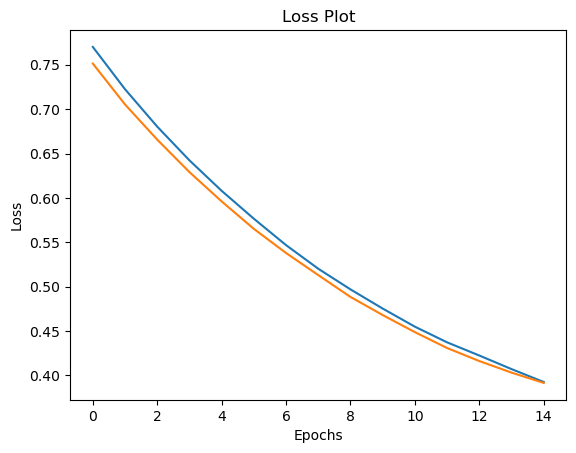

In [70]:
plt.plot(loss_plot)
plt.plot(test_loss_plot)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Plot')
plt.show()

#### NOTE: 
* Due to the difference between the training and testing steps (the use of teacher forcing in training), you may notice that the training loss decreases while the test loss does not.
* This does not indicate overfitting, as the training and testing approaches are fundamentally different and cannot be directly compared.
* If you aim for better results, you can train the model for additional epochs. However, the purpose of this capstone is to demonstrate how to integrate the attention mechanism with the `Encoder-Decoder` architecture for images, rather than to build a `state-of-the-art` model. 

## Step IX : Model Evaluation
1. Implement the evaluation function using a `greedy search` approach.
2. Optionally, define the evaluation function utilizing `beam search`.
3. Evaluate the model on sample data and compute the `BLEU score`.

### 9.1 : Greedy Search

In [71]:
def evaluate(image):
    max_length=max_l
    attention_plot = np.zeros((max_length, attention_features_shape))

    hidden = decoder.init_state(batch_size=1)

    temp_input = tf.expand_dims(load_the_image(image)[0], 0) # process the input image to desired format before extracting features
    img_tensor_val = image_features_extract_model(temp_input)
    img_tensor_val = tf.reshape(img_tensor_val, (img_tensor_val.shape[0], -1, img_tensor_val.shape[3]))

    features = encoder(img_tensor_val)

    dec_input = tf.expand_dims([tokenizer.word_index['<start>']], 0)
    result = []

    for i in range(max_length):
        predictions, hidden, attention_weights = decoder(dec_input, features, hidden)

        attention_plot[i] = tf.reshape(attention_weights, (-1, )).numpy()

        predicted_id = tf.argmax(predictions[0]).numpy()
        result.append(tokenizer.index_word[predicted_id])

        if tokenizer.index_word[predicted_id] == '<end>':
            return result, attention_plot,predictions

        dec_input = tf.expand_dims([predicted_id], 0)

    attention_plot = attention_plot[:len(result), :]

    return result, attention_plot,predictions

### 9.2 : Beam Search(optional)

In [72]:
def beam_evaluate(image, beam_index = 3):
    max_length=max_l
    start = [tokenizer.word_index['<start>']]
    result = [[start, 0.0]]

    attention_plot = np.zeros((max_length, attention_features_shape))

    hidden = decoder.init_state(batch_size=1)

    temp_input = tf.expand_dims(load_the_image(image)[0], 0)
    img_tensor_val = image_features_extract_model(temp_input)
    img_tensor_val = tf.reshape(img_tensor_val, (img_tensor_val.shape[0], -1, img_tensor_val.shape[3]))

    features = encoder(img_tensor_val)

    dec_input = tf.expand_dims([tokenizer.word_index['<start>']], 0)

    while len(result[0][0]) < max_length:
        i=0
        temp = []
        for s in result:
            predictions, hidden, attention_weights = decoder(dec_input, features, hidden)
            attention_plot[i] = tf.reshape(attention_weights, (-1, )).numpy()
            i=i+1
            word_preds = np.argsort(predictions[0])[-beam_index:]
          
            for w in word_preds:
                next_cap, prob = s[0][:], s[1]
                next_cap.append(w)
            
                prob += np.log(predictions[0][w])
                    
                temp.append([next_cap, prob])
        result = temp
        result = sorted(result, reverse=False, key=lambda l: l[1])
        result = result[-beam_index:]
        
        
        predicted_id = result[-1]
        pred_list = predicted_id[0]
        
        prd_id = pred_list[-1] 
        if(prd_id!=3):
            dec_input = tf.expand_dims([prd_id], 0)  
        else:
            break
    
    
    result2 = result[-1][0]
    
    intermediate_caption = [tokenizer.index_word[i] for i in result2]
    final_caption = []
    for i in intermediate_caption:
        if i != '<end>':
            final_caption.append(i)
            
        else:
            break

    attention_plot = attention_plot[:len(result), :]
    final_caption = ' '.join(final_caption[1:])
    
    return final_caption

In [73]:
def plot_attmap(caption, weights, image):

    fig = plt.figure(figsize=(10, 10))
    temp_img = np.array(Image.open(image))
    
    len_cap = len(caption)
    for cap in range(len_cap):
        weights_img = np.reshape(weights[cap], (8,8))
        weights_img = np.array(Image.fromarray(weights_img).resize((224, 224), Image.LANCZOS))
        
        ax = fig.add_subplot(len_cap//2, len_cap//2, cap+1)
        ax.set_title(caption[cap], fontsize=15)
        
        img=ax.imshow(temp_img)
        
        ax.imshow(weights_img, cmap='gist_heat', alpha=0.6,extent=img.get_extent())
        ax.axis('off')
    plt.subplots_adjust(hspace=0.2, wspace=0.2)
    plt.show()

In [74]:
from nltk.translate.bleu_score import sentence_bleu

In [75]:
def filt_text(text):

    filt=['<start>','<unk>','<end>'] 
    temp= text.split()
    [temp.remove(j) for k in filt for j in temp if k==j]
    text=' '.join(temp)
    
    return text

5363
BELU score: 1.7577907065401804e-76
Real Caption: a yellow and white car driving on a track next to each other while spectators and cars can be seen in the background
Prediction Caption: a white and white car racing car on a track


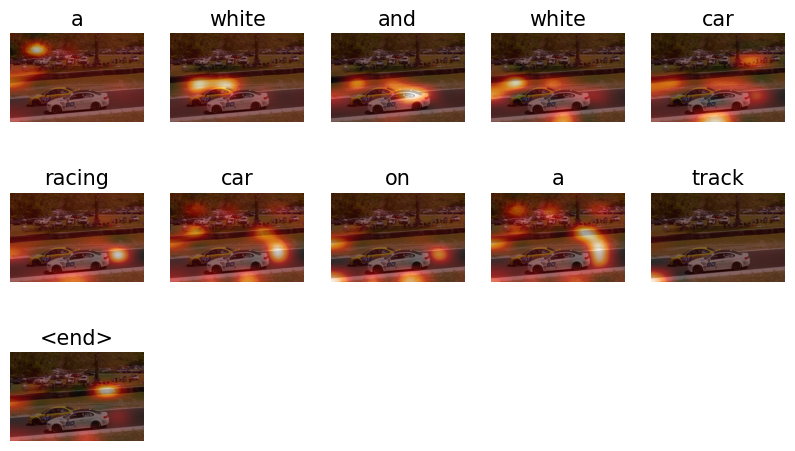

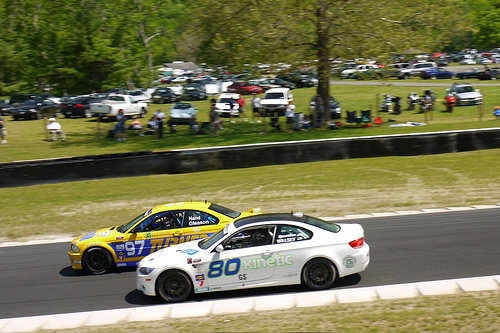

In [76]:
features_shape = batch_f.shape[1]
attention_features_shape = batch_f.shape[0]

rid = np.random.randint(0, len(path_test))
print(rid)
test_image = path_test[rid]

real_caption = ' '.join([tokenizer.index_word[i] for i in cap_test[rid] if i not in [0]])
result, attention_plot,pred_test = evaluate(test_image)


real_caption=filt_text(real_caption)      


pred_caption=' '.join(result).rsplit(' ', 1)[0]

real_appn = []
real_appn.append(real_caption.split())
reference = real_appn
candidate = pred_caption.split()

score = sentence_bleu(reference, candidate, weights=(0.25, 0.25, 0.25, 0.25))
print(f"BELU score: {score*100}")

print('Real Caption:', real_caption)
print('Prediction Caption:', pred_caption)
plot_attmap(result, attention_plot, test_image)


Image.open(test_image)

In [77]:
captions=beam_evaluate(test_image)
print(captions)

a white car


In [1]:
! pip install gTTS


[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [7]:
# Import the required module for text to speech conversion
from gtts import gTTS

# Language in which you want to convert
language = 'en'

# Passing the text and language to the engine,
myobj = gTTS(text=pred_caption, lang=language, slow=False)

# Saving the converted audio in a mp3 file named
myobj.save("Predicted_text.mp3")

# Playing the converted file
os.system("./Predicted_text.mp3")

sh: ./Predicted_text.mp3: Permission denied


32256